# RADAR data exploration

Phase 1 look at the stored data: how much there is, how returns are distributed,
whether volatility clusters, and how the assets move together. Every table comes
from `radar.pipelines.profile`, which also writes `docs/DATA_PROFILE.md`.

Rebuild with `uv run python backend/scripts/build_notebook.py`. Times are UTC.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from radar.db.session import make_engine, session_scope
from radar.pipelines import profile as P
from radar.pipelines.datasets import (
    build_mixed_panel, build_realised_volatility, load_field, stock_daily,
)
from radar.universe import get_universe

plt.rcParams.update({'figure.figsize': (10, 3.6), 'axes.grid': True, 'grid.alpha': 0.3})
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
universe = get_universe()
engine = make_engine()
profile = P.build_profile(engine, universe)
btc, gld = universe.get('BTC/USD'), universe.get('GLD')

## History depth and missing data

In [2]:
profile.coverage

,symbol,timeframe,first,last,bars,missing,missing_share,quote_only_share,outliers
0,BTC/USD,1Hour,2021-01-01 00:00:00+00:00,2026-10-05 07:00:00+00:00,50453,27,0.0005,0.0000,144
1,BTC/USD,1Day,2021-01-01 00:00:00+00:00,2026-10-04 00:00:00+00:00,2103,0,0.0000,0.0000,0
2,GLD,1Hour,2016-01-04 09:00:00+00:00,2026-10-02 23:00:00+00:00,41297,0,0.0000,0.0000,89
3,GLD,1Day,2016-01-04 05:00:00+00:00,2026-10-02 04:00:00+00:00,2703,0,0.0000,0.0000,1
4,ETH/USD,1Hour,2021-01-01 00:00:00+00:00,2026-10-05 07:00:00+00:00,50452,28,0.0006,0.0000,131
5,ETH/USD,1Day,2021-01-01 00:00:00+00:00,2026-10-04 00:00:00+00:00,2103,0,0.0000,0.0000,1
6,SOL/USD,1Hour,2021-06-17 15:00:00+00:00,2026-10-05 07:00:00+00:00,46425,32,0.0007,0.0000,67
7,SOL/USD,1Day,2021-06-17 00:00:00+00:00,2026-10-04 00:00:00+00:00,1936,0,0.0000,0.0000,1
8,PAXG/USD,1Hour,2021-01-01 00:00:00+00:00,2026-10-05 07:00:00+00:00,48479,2001,0.0396,0.0000,107
9,PAXG/USD,1Day,2021-01-01 00:00:00+00:00,2026-10-04 00:00:00+00:00,2103,0,0.0000,0.0000,4


## Prices

Bitcoin from the Kraken feed (2021 on) and gold as GLD (2016 on), log scale.

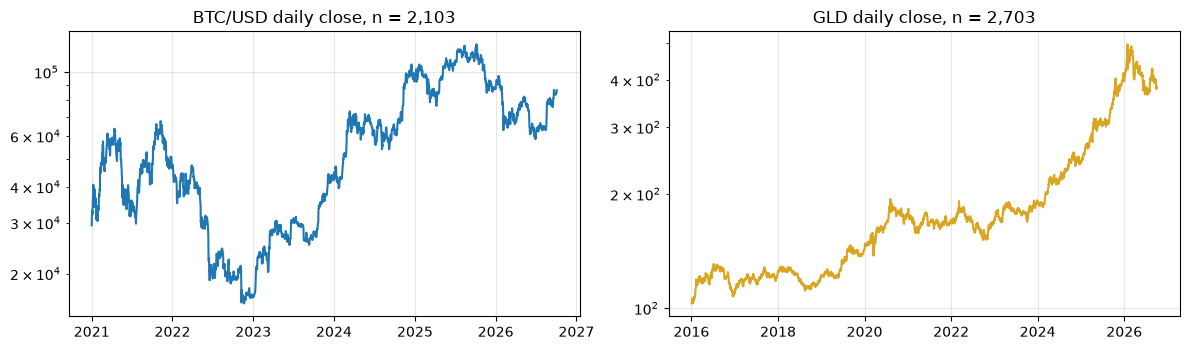

In [3]:
with session_scope(engine) as s:
    btc_close = load_field(s, ['BTC/USD'], '1Day')['BTC/USD'].dropna()
    gld_close = stock_daily(s, ['GLD'])['GLD'].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(btc_close.index, btc_close.values, color='tab:blue')
axes[0].set(title=f'BTC/USD daily close, n = {len(btc_close):,}', yscale='log')
axes[1].plot(gld_close.index, gld_close.values, color='goldenrod')
axes[1].set(title=f'GLD daily close, n = {len(gld_close):,}', yscale='log')
plt.tight_layout()

## Daily return distributions

Bars are the observed returns; the line is a normal distribution with the same
mean and standard deviation. The observed tails are fatter.

In [4]:
profile.returns.set_index('symbol')

,days,mean,std,annual_volatility,skew,excess_kurtosis,worst,best,autocorr_1,squared_autocorr_1,squared_autocorr_5
symbol,,,,,,,,,,,
BTC/USD,2102,0.0005,0.0299,0.5718,-0.1162,4.1077,-0.1680,0.1775,-0.0386,0.1466,0.0953
GLD,2702,0.0005,0.0105,0.1659,-0.6361,7.6187,-0.1084,0.0616,-0.0084,0.1689,0.1324
ETH/USD,2102,0.0006,0.0404,0.7721,-0.1733,5.5426,-0.3237,0.2345,-0.0399,0.1408,0.2002
SOL/USD,1935,0.0006,0.0511,0.9767,-0.5216,9.5959,-0.5538,0.2828,0.0093,0.2312,0.0450
PAXG/USD,2102,0.0004,0.0100,0.1908,-0.6555,11.2512,-0.1076,0.0650,-0.0300,0.1310,0.0593
SPY,2702,0.0006,0.0110,0.1749,-0.5856,13.0681,-0.1141,0.0998,-0.1166,0.3308,0.3083
UUP,2702,0.0001,0.0044,0.0693,-0.0400,4.7360,-0.0326,0.0375,-0.0198,0.3729,0.0986
TLT,2702,-0.0001,0.0092,0.1468,0.0262,5.0825,-0.0690,0.0725,-0.0185,0.4529,0.2798
TIP,2702,0.0001,0.0036,0.0566,0.2492,14.7164,-0.0291,0.0435,0.0821,0.3689,0.1696


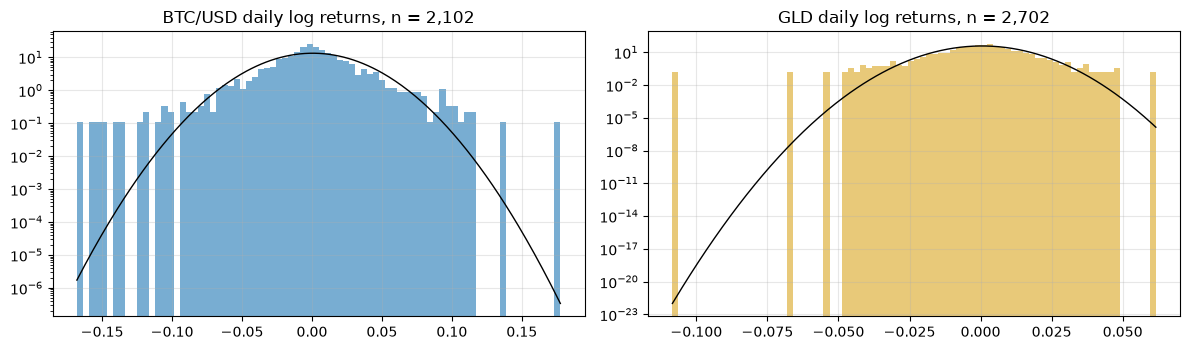

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
with session_scope(engine) as s:
    for ax, asset, colour in ((axes[0], btc, 'tab:blue'), (axes[1], gld, 'goldenrod')):
        r = P.daily_returns(s, asset)
        ax.hist(r, bins=80, density=True, color=colour, alpha=0.6)
        x = np.linspace(r.min(), r.max(), 300)
        ax.plot(x, np.exp(-0.5 * ((x - r.mean()) / r.std()) ** 2) / (r.std() * np.sqrt(2 * np.pi)), 'k', lw=1)
        ax.set(title=f'{asset.symbol} daily log returns, n = {len(r):,}', yscale='log')
plt.tight_layout()

## Volatility clustering

Autocorrelation of squared daily returns. Values that stay above zero mean large
moves follow large moves, which is what the regime model relies on.

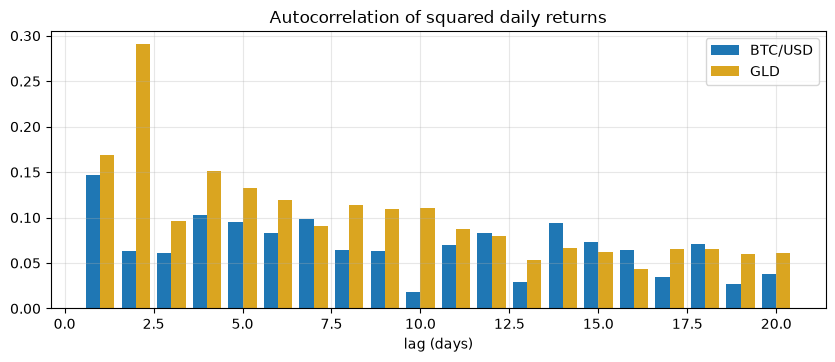

In [6]:
fig, ax = plt.subplots()
lags = range(1, 21)
with session_scope(engine) as s:
    for asset, colour, shift in ((btc, 'tab:blue', -0.2), (gld, 'goldenrod', 0.2)):
        squared = P.daily_returns(s, asset) ** 2
        ax.bar([lag + shift for lag in lags], [squared.autocorr(lag) for lag in lags],
               width=0.4, color=colour, label=asset.symbol)
ax.set(title='Autocorrelation of squared daily returns', xlabel='lag (days)')
ax.legend();

## Realised volatility

Daily realised volatility from hourly bars, with a 30-day median.

In [7]:
profile.volatility.set_index('symbol')

,days,flagged,flagged_share,median,p95,max,log_autocorr_1
symbol,,,,,,,
BTC/USD,2104,1,0.0005,0.0226,0.0559,0.1946,0.5730
GLD,2703,1,0.0004,0.0068,0.0191,0.0725,0.2721
ETH/USD,2104,1,0.0005,0.0295,0.0720,0.2433,0.6163
SOL/USD,1937,2,0.0010,0.0399,0.0877,0.3391,0.6429
PAXG/USD,2104,175,0.0832,0.0087,0.0202,0.2081,0.4473
SPY,2703,1,0.0004,0.0066,0.0193,0.1263,0.6292
UUP,2703,1,0.0004,0.0032,0.0076,0.0491,0.2398
TLT,2703,3,0.0011,0.0067,0.0156,0.0813,0.4083
TIP,2703,1,0.0004,0.0023,0.0060,0.0336,0.4523


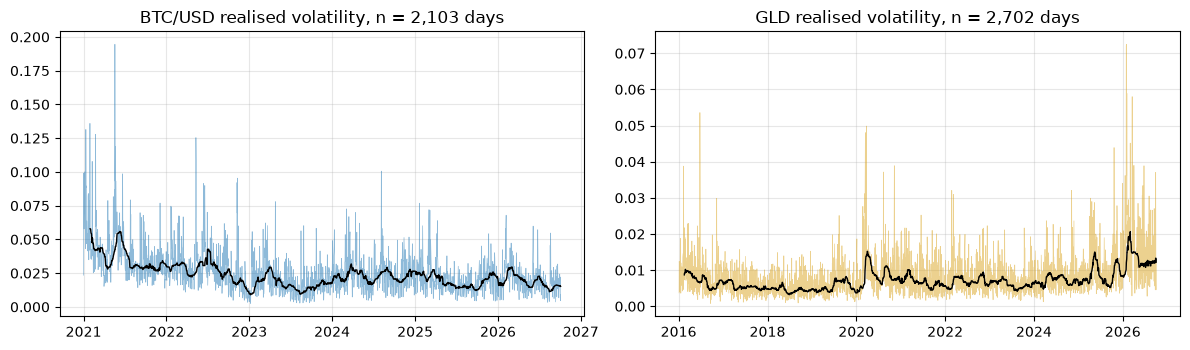

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
with session_scope(engine) as s:
    for ax, asset, colour in ((axes[0], btc, 'tab:blue'), (axes[1], gld, 'goldenrod')):
        rv = build_realised_volatility(s, asset)['rv'].dropna()
        ax.plot(rv.index, rv.values, color=colour, lw=0.5, alpha=0.5)
        ax.plot(rv.index, rv.rolling(30).median().values, color='k', lw=1)
        ax.set(title=f'{asset.symbol} realised volatility, n = {len(rv):,} days')
plt.tight_layout()

## Bitcoin against gold

Rolling 90-session correlation of daily returns on the mixed panel, where a
weekend Bitcoin move is compared with gold's Friday-to-Monday move.

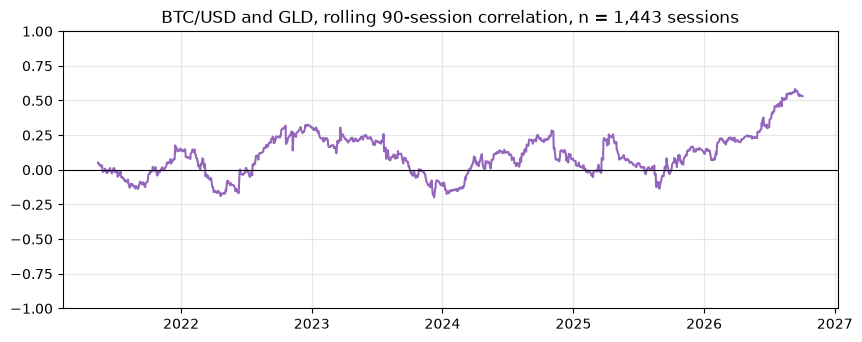

In [9]:
with session_scope(engine) as s:
    mixed = build_mixed_panel(s, universe)
pair = mixed.returns[['BTC/USD', 'GLD']].dropna()
rolling = pair['BTC/USD'].rolling(90).corr(pair['GLD']).dropna()
fig, ax = plt.subplots()
ax.plot(rolling.index, rolling.values, color='tab:purple')
ax.axhline(0, color='k', lw=0.8)
ax.set(title=f'BTC/USD and GLD, rolling 90-session correlation, n = {len(pair):,} sessions', ylim=(-1, 1));

In [10]:
profile.correlation.round(2)

,GLD,SPY,UUP,TLT,TIP,VIXY,BTC/USD,ETH/USD,SOL/USD,PAXG/USD
GLD,1.0000,0.1500,-0.4400,0.2100,0.3300,-0.0600,0.1300,0.1200,0.0900,0.9600
SPY,0.1500,1.0000,-0.2700,0.0800,0.2000,-0.7700,0.4200,0.4500,0.3600,0.1400
UUP,-0.4400,-0.2700,1.0000,-0.2600,-0.3400,0.1400,-0.1800,-0.1700,-0.1500,-0.4100
TLT,0.2100,0.0800,-0.2600,1.0000,0.7500,0.0100,0.0100,0.0100,0.0100,0.1900
TIP,0.3300,0.2000,-0.3400,0.7500,1.0000,-0.0600,0.0900,0.0900,0.0600,0.2900
VIXY,-0.0600,-0.7700,0.1400,0.0100,-0.0600,1.0000,-0.3700,-0.4100,-0.3100,-0.0500
BTC/USD,0.1300,0.4200,-0.1800,0.0100,0.0900,-0.3700,1.0000,0.8400,0.6900,0.1400
ETH/USD,0.1200,0.4500,-0.1700,0.0100,0.0900,-0.4100,0.8400,1.0000,0.7000,0.1400
SOL/USD,0.0900,0.3600,-0.1500,0.0100,0.0600,-0.3100,0.6900,0.7000,1.0000,0.1000
PAXG/USD,0.9600,0.1400,-0.4100,0.1900,0.2900,-0.0500,0.1400,0.1400,0.1000,1.0000


## News articles per month

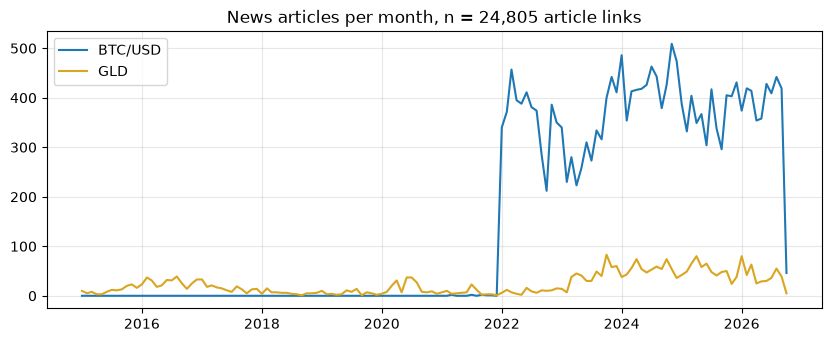

In [11]:
from sqlalchemy import select
from radar.db.models import NewsArticle, NewsSymbol
with session_scope(engine) as s:
    rows = s.execute(select(NewsSymbol.symbol, NewsArticle.created_at)
                     .join(NewsArticle, NewsArticle.id == NewsSymbol.article_id)).all()
news = pd.DataFrame(rows, columns=['symbol', 'created_at'])
news['month'] = pd.to_datetime(news['created_at'], utc=True).dt.tz_localize(None).dt.to_period('M').dt.to_timestamp()
monthly = news.groupby(['month', 'symbol']).size().unstack(fill_value=0)
fig, ax = plt.subplots()
for symbol, colour in (('BTC/USD', 'tab:blue'), ('GLD', 'goldenrod')):
    ax.plot(monthly.index, monthly[symbol].values, color=colour, label=symbol)
ax.set(title=f'News articles per month, n = {len(news):,} article links')
ax.legend();